# 시각화 및 보고서 전 결과정리 


LOADING: easy

LOADING: medium

LOADING: hard


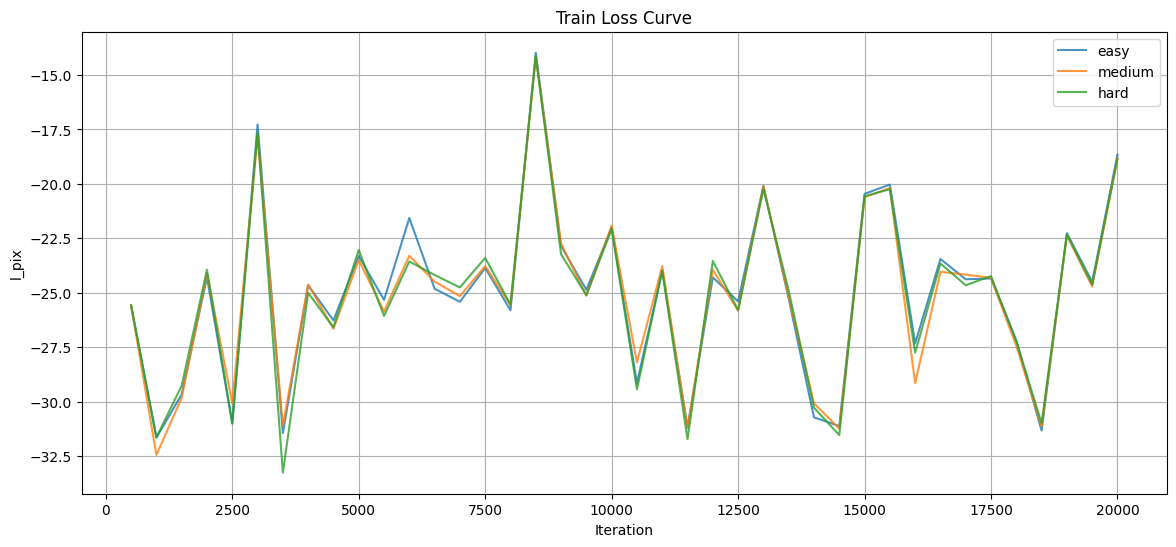

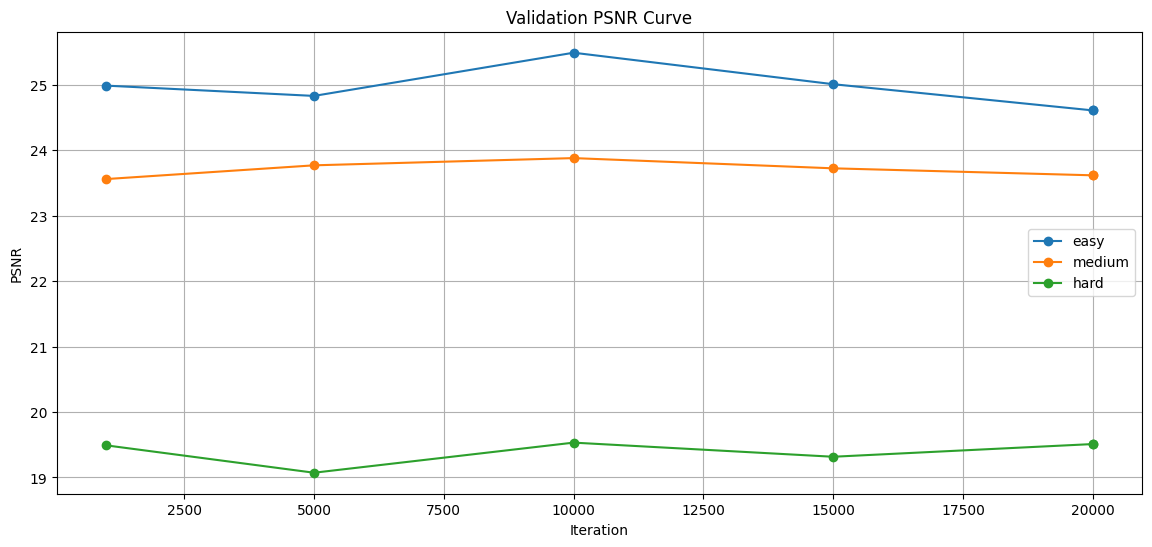

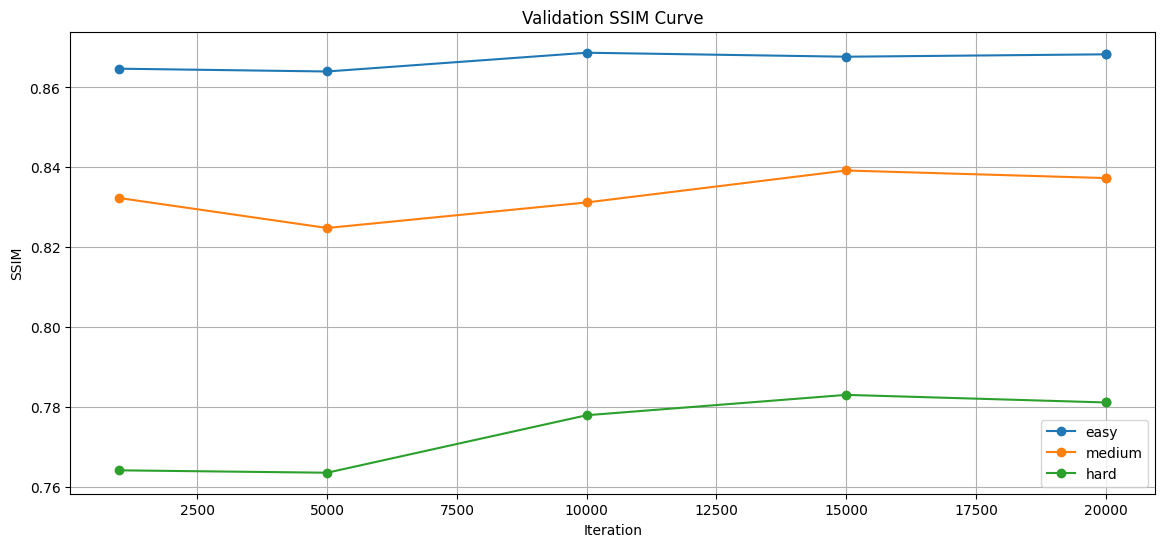


BEST CHECKPOINT SUMMARY

[EASY]
BEST ITER : 10000
BEST PSNR : 25.4881
BEST SSIM : 0.8687

[MEDIUM]
BEST ITER : 10000
BEST PSNR : 23.8785
BEST SSIM : 0.8312

[HARD]
BEST ITER : 10000
BEST PSNR : 19.5326
BEST SSIM : 0.7779


In [ ]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# LOG PATHS
# =========================================================

log_dict = {

    'easy': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-water-easy-w16'
        r'\train_NAFNet-water-easy-w16_20260527_015219.log'
    ),

    'medium': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-water-medium-w16'
        r'\train_NAFNet-water-medium-w16_20260527_074608.log'
    ),

    'hard': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-water-hard-w16'
        r'\train_NAFNet-water-hard-w16_20260527_065513.log'
    )
}

# =========================================================
# REGEX
# =========================================================

train_pattern = re.compile(
    r'iter:\s*([\d,]+).*?l_pix:\s*(-?[0-9.eE+]+)'
)

val_pattern = re.compile(
    r'Validation.*?# psnr:\s*([0-9.]+)\s*# ssim:\s*([0-9.]+)'
)

iter_pattern = re.compile(
    r'iter:\s*([\d,]+)'
)

# =========================================================
# STORAGE
# =========================================================

results = {}

# =========================================================
# PARSE LOGS
# =========================================================

for difficulty, log_path in log_dict.items():

    print(f'\nLOADING: {difficulty}')

    with open(
        log_path,
        'r',
        encoding='utf-8'
    ) as f:

        lines = f.readlines()

    train_iters = []
    train_losses = []

    val_iters = []
    val_psnr = []
    val_ssim = []

    current_iter = None

    for line in lines:

        # -------------------------------------------------
        # CURRENT ITER
        # -------------------------------------------------

        iter_match = iter_pattern.search(line)

        if iter_match:

            current_iter = int(
                iter_match.group(1).replace(',', '')
            )

        # -------------------------------------------------
        # TRAIN LOSS
        # -------------------------------------------------

        train_match = train_pattern.search(line)

        if train_match:

            iteration = int(
                train_match.group(1).replace(',', '')
            )

            loss = float(
                train_match.group(2)
            )

            train_iters.append(iteration)
            train_losses.append(loss)

        # -------------------------------------------------
        # VALIDATION
        # -------------------------------------------------

        val_match = val_pattern.search(line)

        if val_match and current_iter is not None:

            psnr = float(
                val_match.group(1)
            )

            ssim = float(
                val_match.group(2)
            )

            val_iters.append(current_iter)
            val_psnr.append(psnr)
            val_ssim.append(ssim)

    results[difficulty] = {

        'train_iters': train_iters,
        'train_losses': train_losses,

        'val_iters': val_iters,
        'val_psnr': val_psnr,
        'val_ssim': val_ssim
    }

# =========================================================
# FIGURE 1 : TRAIN LOSS
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['train_iters'],
        results[difficulty]['train_losses'],
        label=difficulty,
        alpha=0.8
    )

plt.xlabel('Iteration')
plt.ylabel('l_pix')

plt.title('Train Loss Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FIGURE 2 : VALIDATION PSNR
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['val_iters'],
        results[difficulty]['val_psnr'],
        marker='o',
        label=difficulty
    )

plt.xlabel('Iteration')
plt.ylabel('PSNR')

plt.title('Validation PSNR Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FIGURE 3 : VALIDATION SSIM
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['val_iters'],
        results[difficulty]['val_ssim'],
        marker='o',
        label=difficulty
    )

plt.xlabel('Iteration')
plt.ylabel('SSIM')

plt.title('Validation SSIM Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# BEST CHECKPOINT SUMMARY
# =========================================================

print('\n' + '=' * 70)
print('BEST CHECKPOINT SUMMARY')
print('=' * 70)

for difficulty in results:

    psnr_list = results[difficulty]['val_psnr']

    best_idx = psnr_list.index(
        max(psnr_list)
    )

    best_iter = (
        results[difficulty]['val_iters'][best_idx]
    )

    best_psnr = (
        results[difficulty]['val_psnr'][best_idx]
    )

    best_ssim = (
        results[difficulty]['val_ssim'][best_idx]
    )

    print(f'\n[{difficulty.upper()}]')

    print(f'BEST ITER : {best_iter}')

    print(f'BEST PSNR : {best_psnr:.4f}')

    print(f'BEST SSIM : {best_ssim:.4f}')

1. Train Loss 분석
* Train loss는 전체적으로 감소하는 안정적인 수렴 형태를 보였음.
* 다만 PSNRLoss 특성과 작은 batch size(batch=4) 영향으로 iteration 단위 fluctuation이 크게 관찰됨.
* 현재 variance는 학습 불안정보다는 low-level restoration task 특성에 가까운 것으로 판단됨.
* 특히 patch 기반 학습(64×64)과 augmentation(flip/rotation) 적용으로 mini-batch difficulty variance가 크게 발생하는 것으로 해석 가능.

2. Validation 성능 분석
* 모든 difficulty(easy / medium / hard)에서 약 10000~15000 iteration 부근에서 최고 성능 영역 형성.
* 5000 iteration 이전 구간은 underfitting 경향을 보였음.
* 15000 iteration 이후부터는 성능 plateau 및 약한 overfitting 양상이 일부 관찰됨.
* 현재 baseline 기준 best checkpoint는 10000~15000 iteration 구간으로 추정됨.

3. Difficulty별 Robustness 분석
* Difficulty 증가에 따라 restoration 성능 감소 경향이 명확하게 관찰됨.
* Easy 환경에서는 가장 높은 PSNR/SSIM 성능 유지.
* Medium 및 Hard 환경에서는 degradation intensity 증가에 따라 restoration robustness 감소.
* 해당 결과는 이후 robustness-aware restoration 및 perturbation 기반 실험의 baseline으로 활용 가능.

4. PSNR / SSIM 경향 분석
* PSNR은 10000 iteration 이후 감소 경향을 보였음.
* 반면 일부 구간에서 SSIM은 비교적 유지되거나 증가하는 패턴 확인.
* 이는 구조(structure)는 유지되지만 pixel-level fidelity 측면에서 saturation 또는 overfitting이 발생했을 가능성을 의미함.
* 즉 후반 학습에서는 detail reconstruction보다 structure preservation 경향이 강해지는 것으로 해석 가능.

5. Checkpoint 분석
* 현재 validation/checkpoint 저장 주기가 5000 iteration 단위로 설정되어 있음.
* 따라서 실제 optimal checkpoint가 11000~13000 iteration 부근에 존재할 가능성이 있음.

> 이후 실험에서는:

> val_freq = 1000
> save_checkpoint_freq = 1000

> 으로 조정하여 보다 세밀한 checkpoint 탐색을 수행할 예정.

6. Batch Size 재실험 이유
* 현재 batch size=4 환경에서는 patch difficulty variance가 크게 발생하여 train loss fluctuation이 크게 나타남.
* Batch size를 증가시키면 gradient estimation variance 감소 및 convergence 안정화 효과 기대 가능.
* 또한 validation metric fluctuation 감소 가능성도 존재.
* 현재 모델(width=16) 및 patch size(64×64) 기준 VRAM 여유가 충분한 것으로 확인되어 batch size=8 실험을 우선적으로 수행할 예정.

## Train구체적으로 하기 
* batchsize 4 -> 64
* lr 1e-3 -> 1e-4
* valid 1000단위 마다 출력 


LOADING: easy

LOADING: medium

LOADING: hard


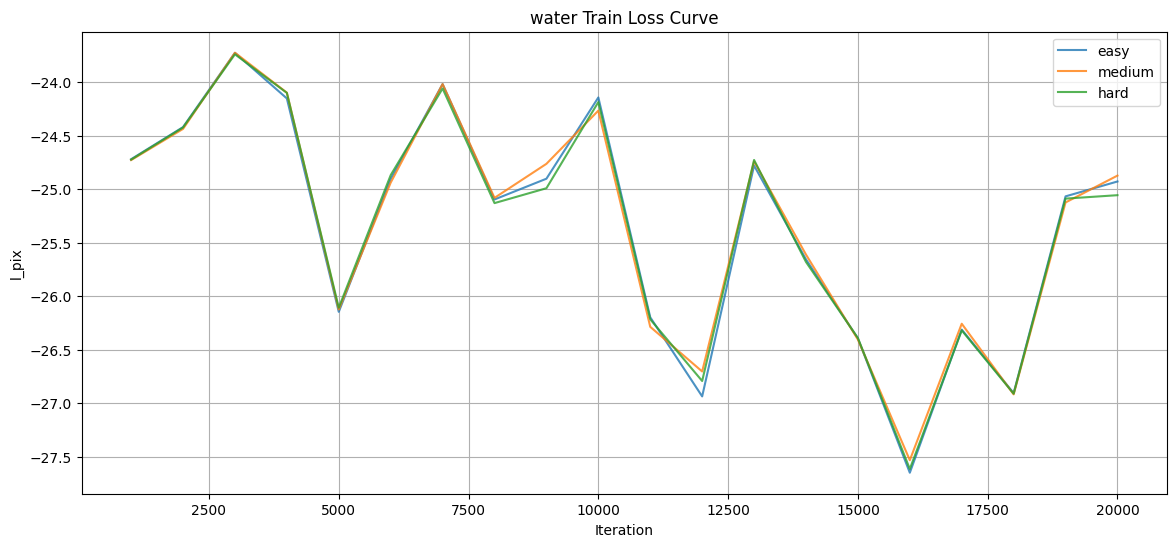

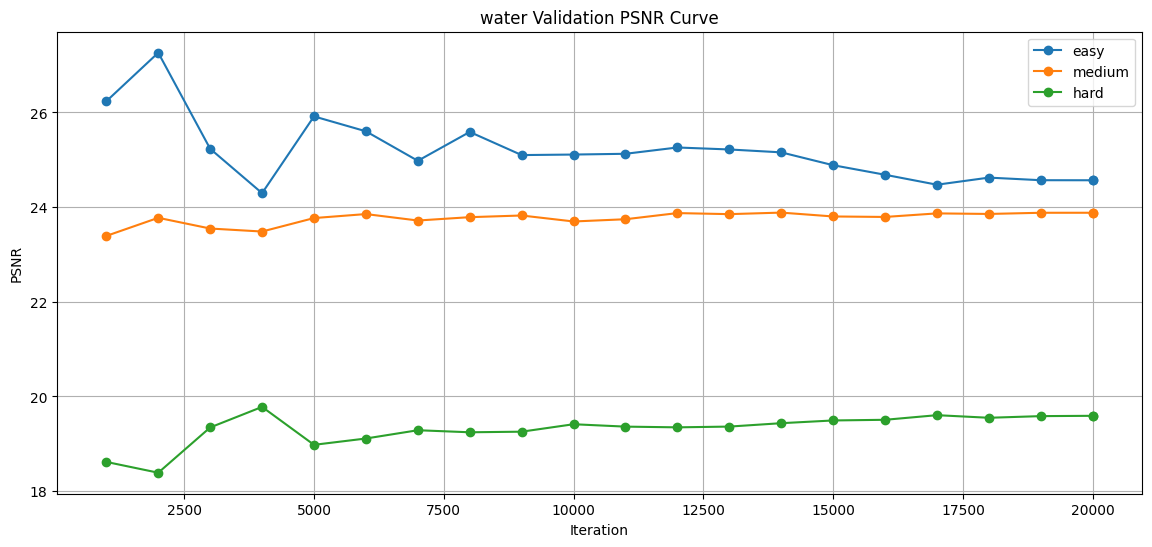

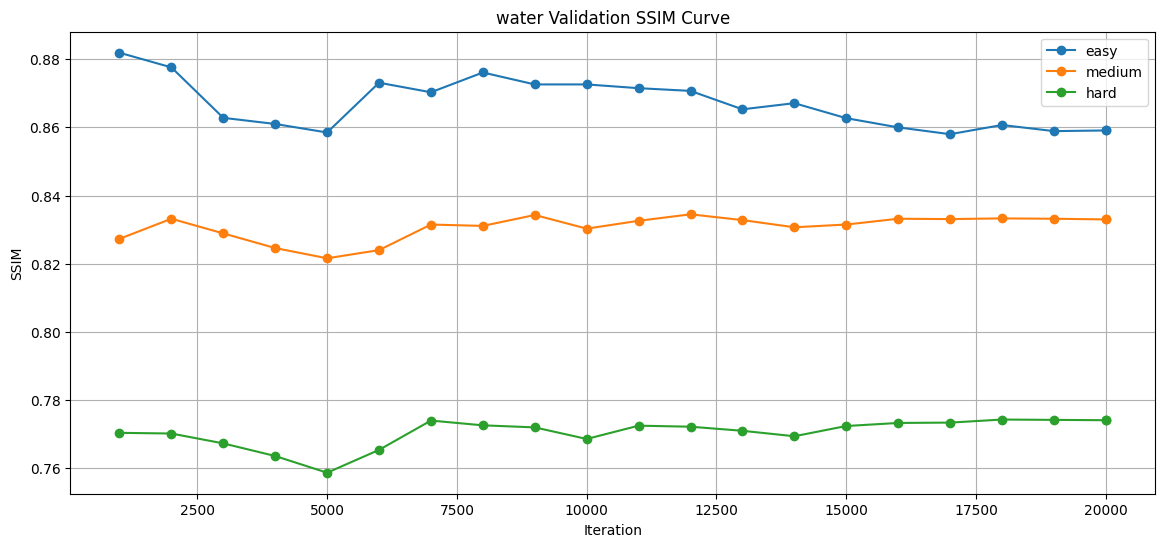


BEST CHECKPOINT SUMMARY

[EASY]
BEST ITER : 2000
BEST PSNR : 27.2620
BEST SSIM : 0.8776

[MEDIUM]
BEST ITER : 14000
BEST PSNR : 23.8838
BEST SSIM : 0.8307

[HARD]
BEST ITER : 4000
BEST PSNR : 19.7782
BEST SSIM : 0.7636


In [2]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

log_dict = {

    'easy': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-water-easy-w32'
        r'\train_NAFNet-water-easy-w32_20260603_214052.log'
    ),

    'medium': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-water-medium-w32'
        r'\train_NAFNet-water-medium-w32_20260604_034234.log'
    ),

    'hard': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-water-hard-w32'
        r'\train_NAFNet-water-hard-w32_20260604_003953.log'
    )
}


# =========================================================
# REGEX
# =========================================================

train_pattern = re.compile(
    r'iter:\s*([\d,]+).*?l_pix:\s*(-?[0-9.eE+]+)'
)

val_pattern = re.compile(
    r'Validation.*?# psnr:\s*([0-9.]+)\s*# ssim:\s*([0-9.]+)'
)

iter_pattern = re.compile(
    r'iter:\s*([\d,]+)'
)

# =========================================================
# STORAGE
# =========================================================

results = {}

# =========================================================
# PARSE LOGS
# =========================================================

for difficulty, log_path in log_dict.items():

    print(f'\nLOADING: {difficulty}')

    with open(
        log_path,
        'r',
        encoding='utf-8'
    ) as f:

        lines = f.readlines()

    train_iters = []
    train_losses = []

    val_iters = []
    val_psnr = []
    val_ssim = []

    current_iter = None

    for line in lines:

        # -------------------------------------------------
        # CURRENT ITER
        # -------------------------------------------------

        iter_match = iter_pattern.search(line)

        if iter_match:

            current_iter = int(
                iter_match.group(1).replace(',', '')
            )

        # -------------------------------------------------
        # TRAIN LOSS
        # -------------------------------------------------

        train_match = train_pattern.search(line)

        if train_match:

            iteration = int(
                train_match.group(1).replace(',', '')
            )

            loss = float(
                train_match.group(2)
            )

            train_iters.append(iteration)
            train_losses.append(loss)

        # -------------------------------------------------
        # VALIDATION
        # -------------------------------------------------

        val_match = val_pattern.search(line)

        if val_match and current_iter is not None:

            psnr = float(
                val_match.group(1)
            )

            ssim = float(
                val_match.group(2)
            )

            val_iters.append(current_iter)
            val_psnr.append(psnr)
            val_ssim.append(ssim)

    results[difficulty] = {

        'train_iters': train_iters,
        'train_losses': train_losses,

        'val_iters': val_iters,
        'val_psnr': val_psnr,
        'val_ssim': val_ssim
    }

# =========================================================
# FIGURE 1 : TRAIN LOSS
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['train_iters'],
        results[difficulty]['train_losses'],
        label=difficulty,
        alpha=0.8
    )

plt.xlabel('Iteration')
plt.ylabel('l_pix')

plt.title('water Train Loss Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FIGURE 2 : VALIDATION PSNR
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['val_iters'],
        results[difficulty]['val_psnr'],
        marker='o',
        label=difficulty
    )

plt.xlabel('Iteration')
plt.ylabel('PSNR')

plt.title('water Validation PSNR Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FIGURE 3 : VALIDATION SSIM
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['val_iters'],
        results[difficulty]['val_ssim'],
        marker='o',
        label=difficulty
    )

plt.xlabel('Iteration')
plt.ylabel('SSIM')

plt.title('water Validation SSIM Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# BEST CHECKPOINT SUMMARY
# =========================================================

print('\n' + '=' * 70)
print('BEST CHECKPOINT SUMMARY')
print('=' * 70)

for difficulty in results:

    psnr_list = results[difficulty]['val_psnr']

    best_idx = psnr_list.index(
        max(psnr_list)
    )

    best_iter = (
        results[difficulty]['val_iters'][best_idx]
    )

    best_psnr = (
        results[difficulty]['val_psnr'][best_idx]
    )

    best_ssim = (
        results[difficulty]['val_ssim'][best_idx]
    )

    print(f'\n[{difficulty.upper()}]')

    print(f'BEST ITER : {best_iter}')

    print(f'BEST PSNR : {best_psnr:.4f}')

    print(f'BEST SSIM : {best_ssim:.4f}')

# mixed task도 똑같이 찍어보기 



LOADING: easy

LOADING: medium

LOADING: hard


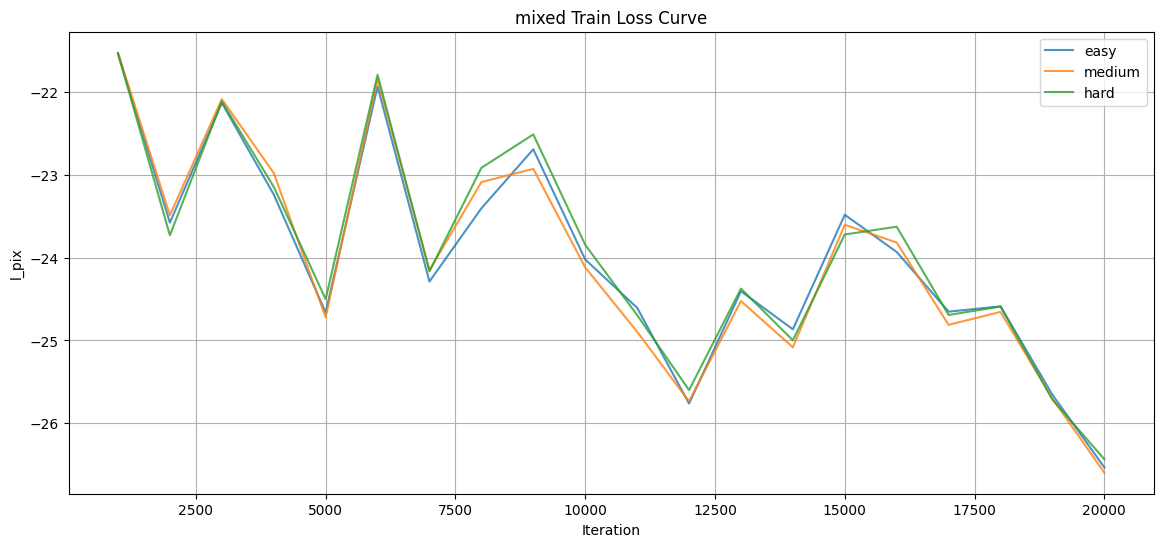

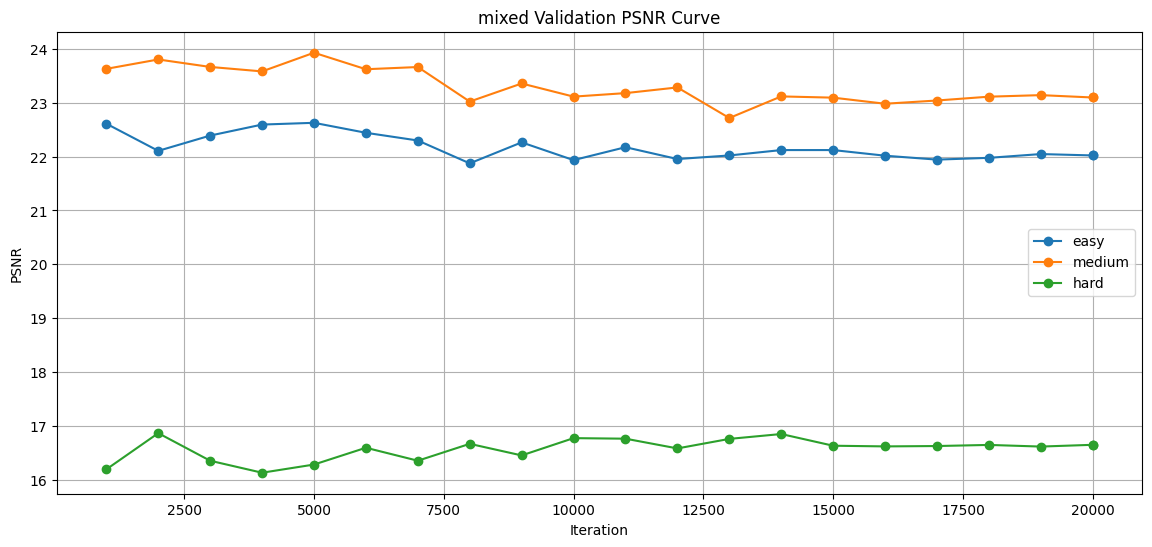

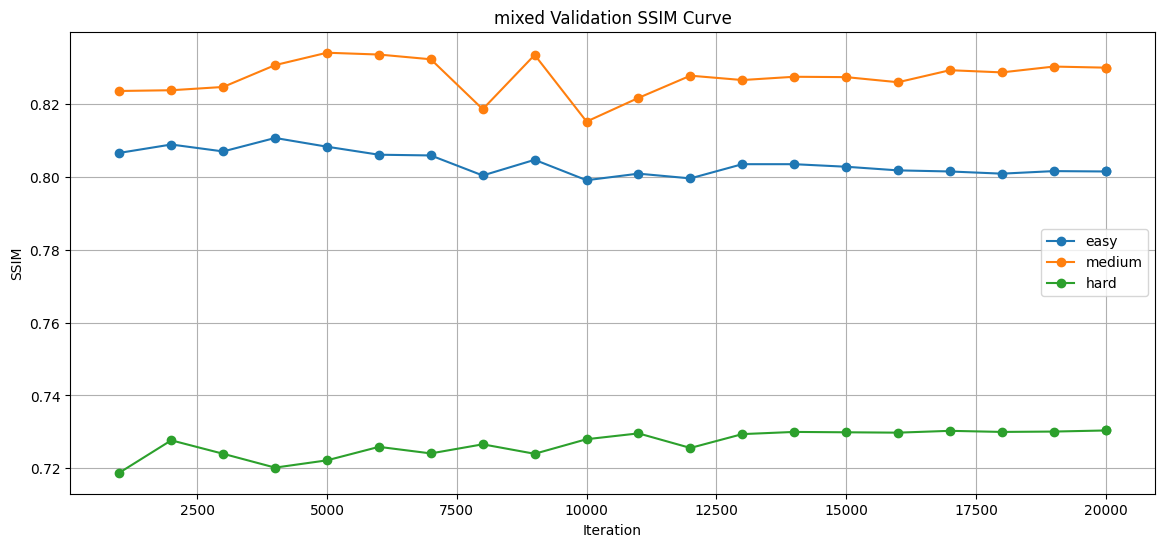


BEST CHECKPOINT SUMMARY

[EASY]
BEST ITER : 5000
BEST PSNR : 22.6261
BEST SSIM : 0.8083

[MEDIUM]
BEST ITER : 5000
BEST PSNR : 23.9262
BEST SSIM : 0.8341

[HARD]
BEST ITER : 2000
BEST PSNR : 16.8692
BEST SSIM : 0.7277


In [3]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

log_dict = {

    'easy': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-mixed-easy-w16'
        r'\train_NAFNet-mixed-easy-w16_20260604_094627.log'
    ),

    'medium': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-mixed-medium-w16'
        r'\train_NAFNet-mixed-medium-w16_20260604_160536.log'
    ),

    'hard': (
        r'C:\DNN\deepLearning\NAFNet\experiments'
        r'\NAFNet-mixed-hard-w16'
        r'\train_NAFNet-mixed-hard-w16_20260604_125217.log'
    )
}


# =========================================================
# REGEX
# =========================================================

train_pattern = re.compile(
    r'iter:\s*([\d,]+).*?l_pix:\s*(-?[0-9.eE+]+)'
)

val_pattern = re.compile(
    r'Validation.*?# psnr:\s*([0-9.]+)\s*# ssim:\s*([0-9.]+)'
)

iter_pattern = re.compile(
    r'iter:\s*([\d,]+)'
)

# =========================================================
# STORAGE
# =========================================================

results = {}

# =========================================================
# PARSE LOGS
# =========================================================

for difficulty, log_path in log_dict.items():

    print(f'\nLOADING: {difficulty}')

    with open(
        log_path,
        'r',
        encoding='utf-8'
    ) as f:

        lines = f.readlines()

    train_iters = []
    train_losses = []

    val_iters = []
    val_psnr = []
    val_ssim = []

    current_iter = None

    for line in lines:

        # -------------------------------------------------
        # CURRENT ITER
        # -------------------------------------------------

        iter_match = iter_pattern.search(line)

        if iter_match:

            current_iter = int(
                iter_match.group(1).replace(',', '')
            )

        # -------------------------------------------------
        # TRAIN LOSS
        # -------------------------------------------------

        train_match = train_pattern.search(line)

        if train_match:

            iteration = int(
                train_match.group(1).replace(',', '')
            )

            loss = float(
                train_match.group(2)
            )

            train_iters.append(iteration)
            train_losses.append(loss)

        # -------------------------------------------------
        # VALIDATION
        # -------------------------------------------------

        val_match = val_pattern.search(line)

        if val_match and current_iter is not None:

            psnr = float(
                val_match.group(1)
            )

            ssim = float(
                val_match.group(2)
            )

            val_iters.append(current_iter)
            val_psnr.append(psnr)
            val_ssim.append(ssim)

    results[difficulty] = {

        'train_iters': train_iters,
        'train_losses': train_losses,

        'val_iters': val_iters,
        'val_psnr': val_psnr,
        'val_ssim': val_ssim
    }

# =========================================================
# FIGURE 1 : TRAIN LOSS
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['train_iters'],
        results[difficulty]['train_losses'],
        label=difficulty,
        alpha=0.8
    )

plt.xlabel('Iteration')
plt.ylabel('l_pix')

plt.title('mixed Train Loss Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FIGURE 2 : VALIDATION PSNR
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['val_iters'],
        results[difficulty]['val_psnr'],
        marker='o',
        label=difficulty
    )

plt.xlabel('Iteration')
plt.ylabel('PSNR')

plt.title('mixed Validation PSNR Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# FIGURE 3 : VALIDATION SSIM
# =========================================================

plt.figure(figsize=(14, 6))

for difficulty in results:

    plt.plot(
        results[difficulty]['val_iters'],
        results[difficulty]['val_ssim'],
        marker='o',
        label=difficulty
    )

plt.xlabel('Iteration')
plt.ylabel('SSIM')

plt.title('mixed Validation SSIM Curve')

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# BEST CHECKPOINT SUMMARY
# =========================================================

print('\n' + '=' * 70)
print('BEST CHECKPOINT SUMMARY')
print('=' * 70)

for difficulty in results:

    psnr_list = results[difficulty]['val_psnr']

    best_idx = psnr_list.index(
        max(psnr_list)
    )

    best_iter = (
        results[difficulty]['val_iters'][best_idx]
    )

    best_psnr = (
        results[difficulty]['val_psnr'][best_idx]
    )

    best_ssim = (
        results[difficulty]['val_ssim'][best_idx]
    )

    print(f'\n[{difficulty.upper()}]')

    print(f'BEST ITER : {best_iter}')

    print(f'BEST PSNR : {best_psnr:.4f}')

    print(f'BEST SSIM : {best_ssim:.4f}')